<a href="https://colab.research.google.com/github/FransHutagalung/AnomaliUdara/blob/main/Project_Final_Bootcamp_Imilkom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Final Project


#### Deteksi Anomali Kualitas Udara Berbasis Data IoT Menggunakan Isolation Forest

### Deskripsi Project



---

#### 📌  Deteksi Anomali Kualitas Udara Berbasis IoT dengan Isolation Forest

Proyek ini merupakan implementasi sistem deteksi anomali pada data kualitas udara yang dikumpulkan dari **perangkat IoT buatan sendiri**. Sistem ini dirancang untuk membantu proses **monitoring lingkungan** secara real-time dengan mendeteksi nilai-nilai sensor yang tidak normal atau menyimpang (anomali), yang dapat menjadi indikasi awal terhadap potensi masalah seperti kebakaran, kerusakan sistem ventilasi, atau pencemaran udara.

#### 🔧 Komponen Proyek:

##### 1. **Sumber Data - IoT Sensor**
Perangkat IoT yang saya kembangkan secara mandiri digunakan untuk mengumpulkan data dari berbagai sensor lingkungan, yang meliputi:
- **Suhu ruangan**
- **Kelembapan udara**
- **Kadar karbonmonoksida (CO)**
- **Indeks kualitas udara (AQI)**

##### 2. **Preprocessing**
Data mentah dari sensor diproses dengan beberapa tahap penting:
- Pembersihan dari nilai ekstrem (outlier ekstrim)
- Standarisasi skala fitur menggunakan `StandardScaler` dan `RobustScaler`
- Reduksi dimensi menggunakan **Principal Component Analysis (PCA)** untuk memvisualisasikan distribusi data

##### 3. **Model Deteksi Anomali - Isolation Forest**
Saya menggunakan **algoritma Isolation Forest** dari `scikit-learn`, yang sangat efektif untuk mendeteksi anomali dalam dataset berdimensi tinggi. Model dilatih hanya dengan data normal untuk mempelajari pola distribusi yang wajar, lalu digunakan untuk:
- Memberikan skor anomali pada data baru
- Mengklasifikasikan data sebagai `normal (1)` atau `anomali (-1)`

##### 4. **Visualisasi**
Untuk membantu pemantauan dan interpretasi hasil, dibuat visualisasi distribusi data menggunakan hasil dari PCA, dengan label warna untuk anomali dan data normal.

##### 5. **Prediksi Input Baru**
Model ini juga memungkinkan pengguna untuk memasukkan data sensor secara manual (suhu, kelembapan, CO, kualitas udara) dan langsung mendapatkan hasil prediksi apakah nilai tersebut normal atau anomali.


#### 📌  Tujuan
Untuk memprediksi kualitas udara yang bersifat anomali yang nantinya dipakai untuk perhatian keamanan pada project iot x machine learning lanjutan





In [60]:
from IPython.display import Image

Image(url='https://res.cloudinary.com/dz7ijhn3x/image/upload/v1746095662/drive/qq1y9afavrdxtisj4lhy.jpg' , width=800)

### Instalasi Dependensi


Mengambil data .csv yang akan dilatih dari google drive

In [28]:
!pip install gdown
!gdown --fuzzy "https://drive.google.com/file/d/1a873EQRgpirtNk2eqimIamgRoT37KMvj/view?usp=drive_link"

Downloading...
From: https://drive.google.com/uc?id=1a873EQRgpirtNk2eqimIamgRoT37KMvj
To: /content/kualitas_udara.csv
100% 46.6k/46.6k [00:00<00:00, 42.7MB/s]


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler , RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split , GridSearchCV , KFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
from sklearn.inspection import permutation_importance
import umap

### Load Data

In [30]:
df = pd.read_csv('/content/kualitas_udara.csv')
df.head()

,id,suhu,kelembaban,karbonmonoksida,kualitasudara,status_alarm,waktu
0,10,34.2,49,2219,349,0,2025-05-01 10:10:39
1,11,34.2,48,2206,350,0,2025-05-01 10:11:09
2,12,34.7,48,2197,346,0,2025-05-01 10:11:39
3,13,34.7,48,2187,350,0,2025-05-01 10:12:09
4,14,34.7,48,2191,348,0,2025-05-01 10:12:39


### Data Cleaning

Menghapus Kolom Id dan Waktu karena tidak terlalu dibutuhkan

In [31]:
df.drop(columns=['id', 'waktu'], inplace=True)

Melihat Informasi dari data frame

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 803 entries, 0 to 802
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   suhu             803 non-null    float64
 1   kelembaban       803 non-null    int64  
 2   karbonmonoksida  803 non-null    int64  
 3   kualitasudara    803 non-null    int64  
 4   status_alarm     803 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 31.5 KB


Melihat Data yang duplikat

In [33]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
798,False
799,False
800,False
801,False


Menghitung total dari data duplikat

In [34]:
df.duplicated().sum()

np.int64(25)

Menghapus data duplikat langsung ke file aslinya

In [35]:
df.drop_duplicates(inplace=True)

Menghitung ulang total data duplikat

In [36]:
df.duplicated().sum()

np.int64(0)

Menghitung total data yang kosong

In [37]:
df.isna().sum()

,0
suhu,0
kelembaban,0
karbonmonoksida,0
kualitasudara,0
status_alarm,0


Melihat data dari table pada kolom suhu

In [38]:
df['suhu']

,suhu
0,34.2
1,34.2
2,34.7
3,34.7
4,34.7
...,...
798,35.6
799,35.6
800,35.6
801,35.6


### Visualisasi Data

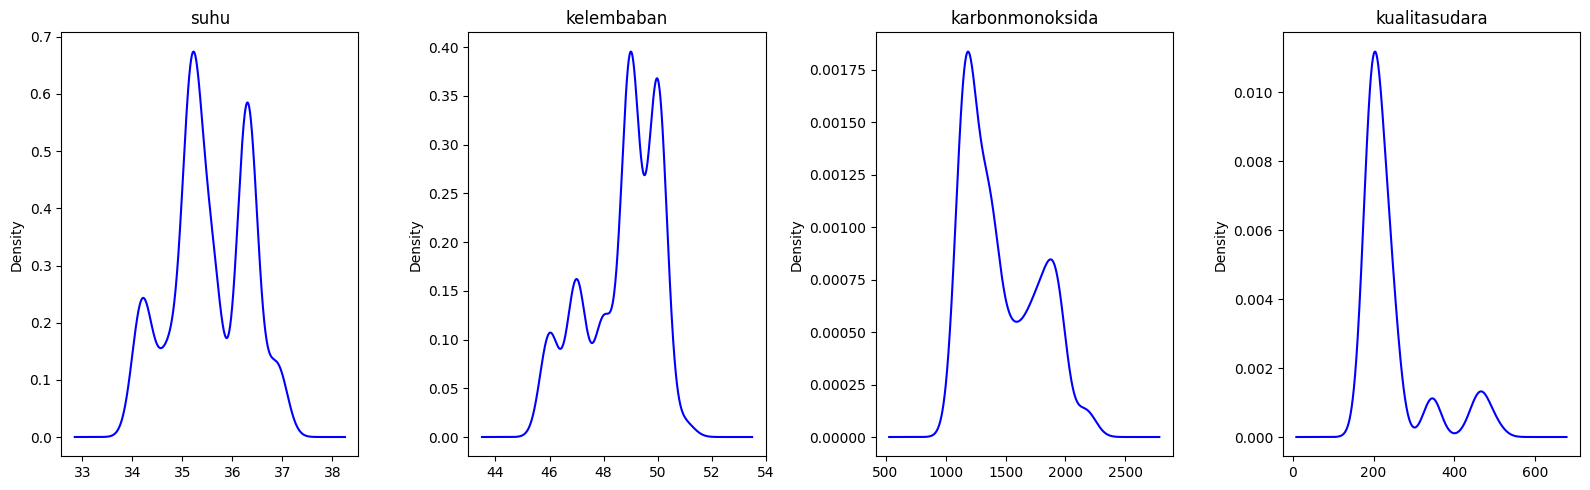

In [42]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16, 5))

for axes, column in zip(ax, df.columns):
    df[column].plot(kind='kde', ax=axes, color='blue', title=column)

plt.tight_layout()
plt.show()

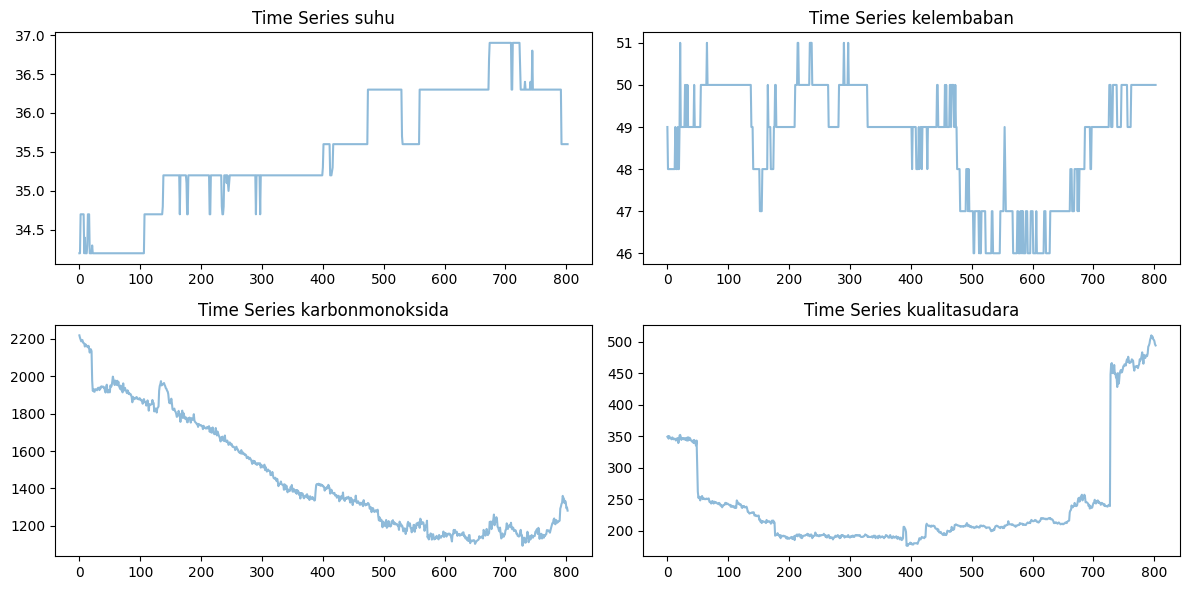

In [43]:
plt.figure(figsize=(12,6))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    plt.plot(df[col], alpha=0.5)
    plt.title(f'Time Series {col}')
plt.tight_layout()
plt.show()

In [44]:
fig = px.scatter_3d(df, x='suhu', y='kelembaban', z='karbonmonoksida',
                    color='kualitasudara', opacity=0.7,
                    title='3D Interactive Scatter Plot')
fig.show()


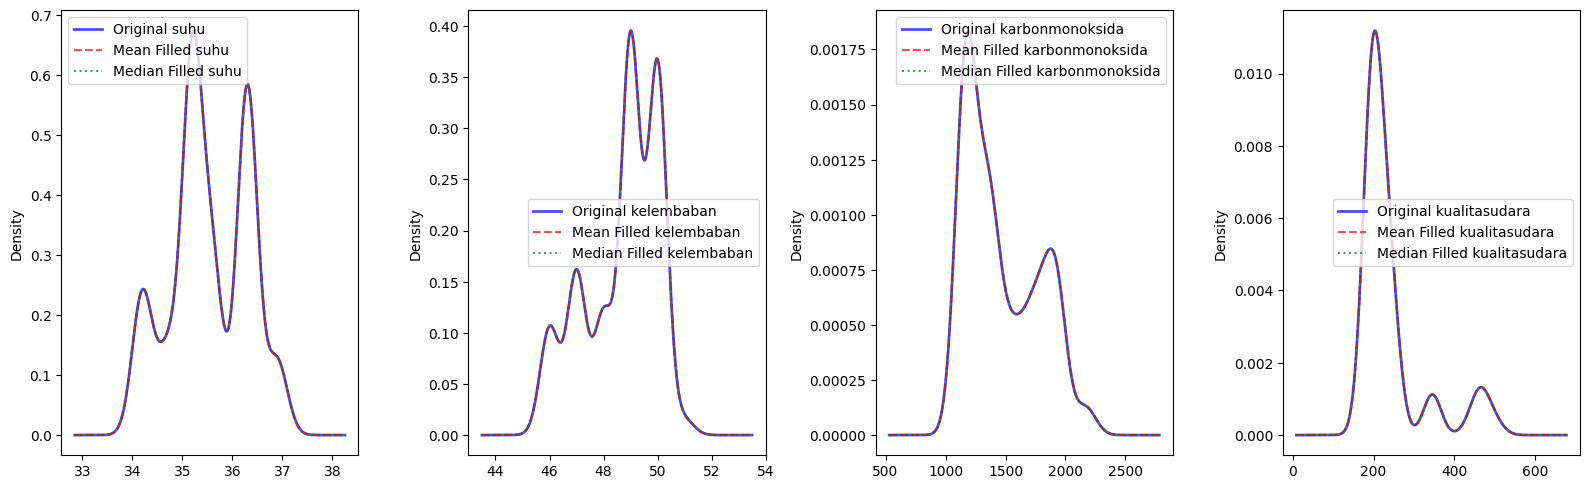

In [45]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))


for axes, column in zip(ax, df.columns):
  mean_filled = df[column].fillna(df[column].mean())
  median_filled = df[column].fillna(df[column].median())
  df.plot(kind='kde', y=column, ax=axes, color='blue', alpha=0.7, linewidth=2, label=f'Original {column}')
  mean_filled.plot(kind='kde', y=column, ax=axes, color='red', alpha=0.7, linestyle='--', label=f'Mean Filled {column}')
  median_filled.plot(kind='kde', y=column, ax=axes, color='green', alpha=0.7, linestyle=':', label=f'Median Filled {column}')

  axes.legend()

plt.tight_layout()
plt.show()

### Outlier

In [46]:

for col in df.columns:
      df.loc[:, col] = df[col].fillna(df[col].median())


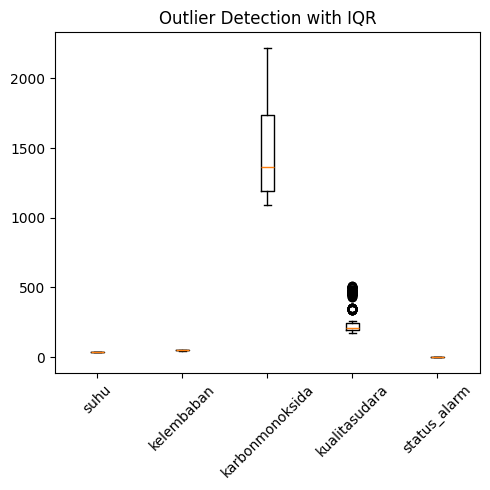

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

numeric_cols = [col for col in df.select_dtypes(include='number').columns ]

positions = range(len(numeric_cols))

for i, col in enumerate(numeric_cols):
    ax.boxplot(df[col].dropna(), positions=[positions[i]])

ax.set_xticks(positions)
ax.set_xticklabels(numeric_cols, rotation=45)

plt.title('Outlier Detection with IQR')
plt.tight_layout()
plt.show()


### Deteksi Outlier

In [48]:
def outlier_detection(data):
  IQR = np.quantile(data, 0.75) - np.quantile(data, 0.25)
  lower_bound = np.quantile(data, 0.25) - 1.5 * IQR
  upper_bound = np.quantile(data, 0.75) + 1.5 * IQR
  outliers = np.where((data < lower_bound) | (data > upper_bound), 1, 0)
  return outliers

In [49]:
for column in df.columns:
      df[column + '_outlier'] = outlier_detection(df[column])


In [50]:
df.head()

,suhu,kelembaban,karbonmonoksida,kualitasudara,status_alarm,suhu_outlier,kelembaban_outlier,karbonmonoksida_outlier,kualitasudara_outlier,status_alarm_outlier
0,34.2,49,2219,349,0,0,0,0,1,0
1,34.2,48,2206,350,0,0,0,0,1,0
2,34.7,48,2197,346,0,0,0,0,1,0
3,34.7,48,2187,350,0,0,0,0,1,0
4,34.7,48,2191,348,0,0,0,0,1,0


In [51]:
for column in df.columns[-5:]:
  print(f"Outliers in {column}: {df[column].sum()}")

Outliers in suhu_outlier: 0
Outliers in kelembaban_outlier: 0
Outliers in karbonmonoksida_outlier: 0
Outliers in kualitasudara_outlier: 121
Outliers in status_alarm_outlier: 0


In [52]:
def drop_outliers(df):
    outlier_cols = df.columns[-3::]
    df_no_outliers = df[~(df[outlier_cols] == 1).any(axis=1)]
    return df_no_outliers

In [53]:
df_copy = df.copy()
df_copy = drop_outliers(df_copy)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 657 entries, 50 to 727
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   suhu                     657 non-null    float64
 1   kelembaban               657 non-null    int64  
 2   karbonmonoksida          657 non-null    int64  
 3   kualitasudara            657 non-null    int64  
 4   status_alarm             657 non-null    int64  
 5   suhu_outlier             657 non-null    int64  
 6   kelembaban_outlier       657 non-null    int64  
 7   karbonmonoksida_outlier  657 non-null    int64  
 8   kualitasudara_outlier    657 non-null    int64  
 9   status_alarm_outlier     657 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 56.5 KB


In [54]:
df.drop(columns=df.columns[-6::], inplace=True)

In [55]:
df.head()

,suhu,kelembaban,karbonmonoksida,kualitasudara
0,34.2,49,2219,349
1,34.2,48,2206,350
2,34.7,48,2197,346
3,34.7,48,2187,350
4,34.7,48,2191,348


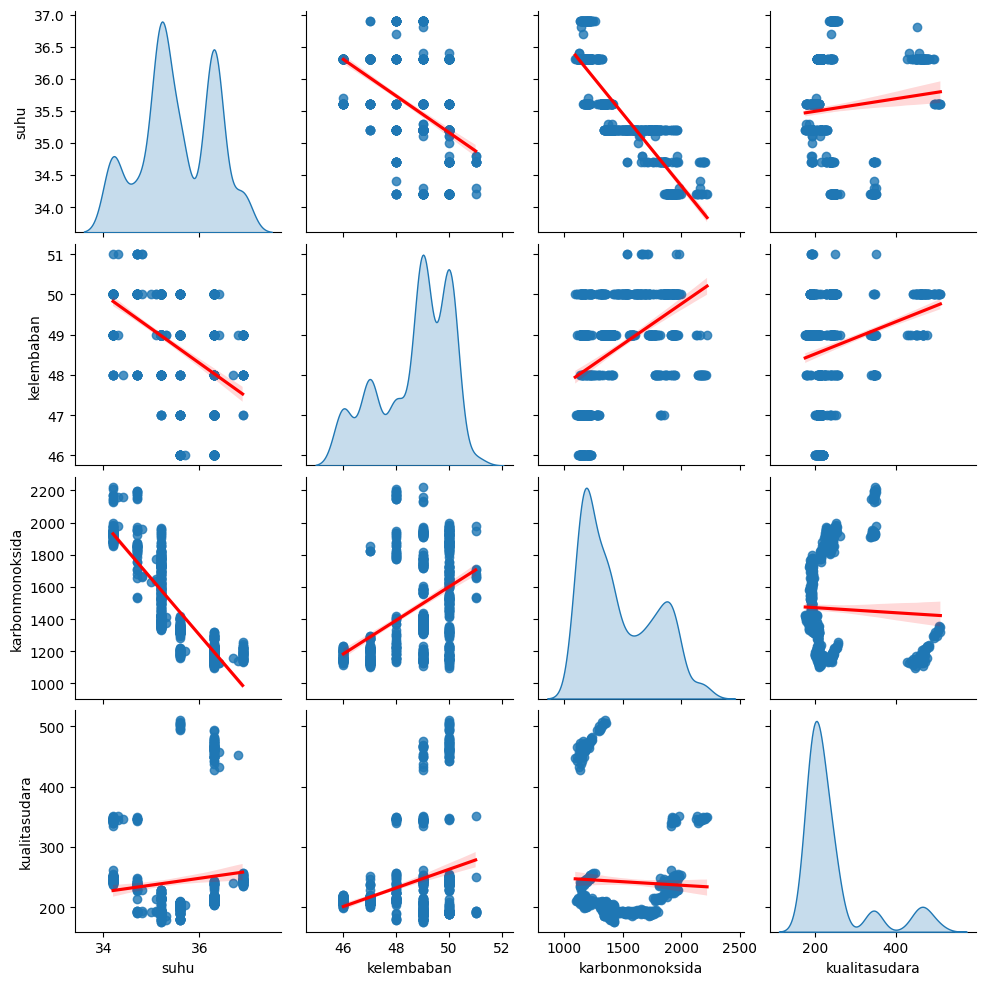

In [56]:
sns.pairplot(data=df, kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.show()

In [57]:
df.head()

,suhu,kelembaban,karbonmonoksida,kualitasudara
0,34.2,49,2219,349
1,34.2,48,2206,350
2,34.7,48,2197,346
3,34.7,48,2187,350
4,34.7,48,2191,348


### Korelasi Pearson dan Spearman

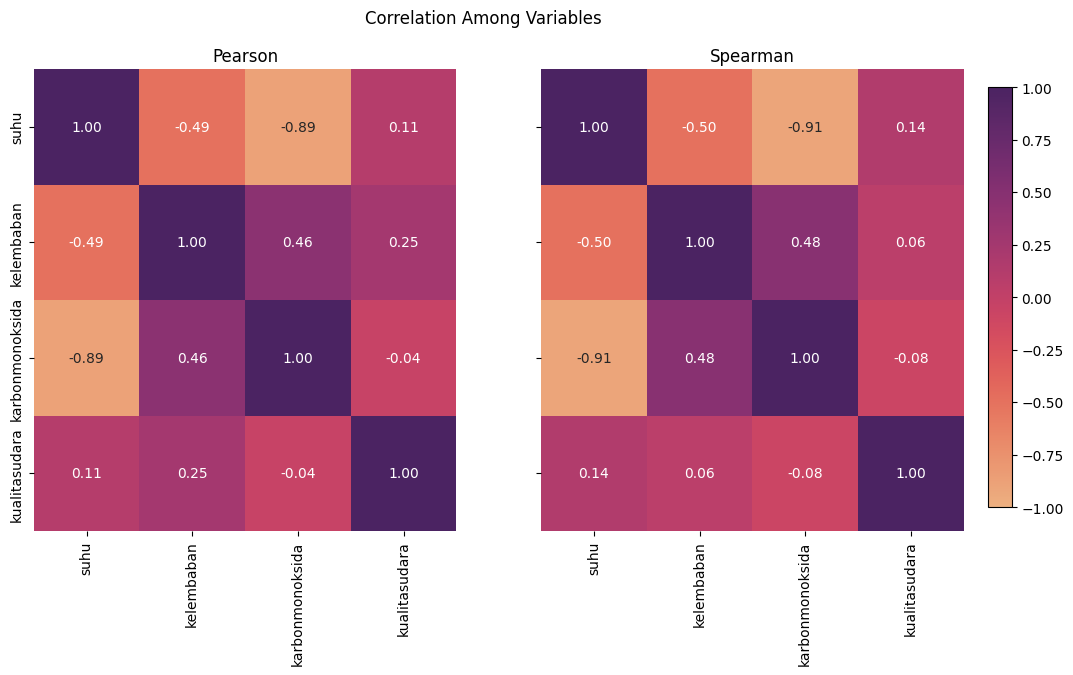

In [58]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
annot = True
fmt = '.2f'
cmap = 'flare'

sns.heatmap(df.corr(method='pearson'), annot=annot, vmin=-1, vmax=1, fmt=fmt, cmap=cmap, ax=ax[0], cbar=False)
sns.heatmap(df.corr(method='spearman'), annot=annot, vmin=-1, vmax=1, fmt=fmt, cmap=cmap, ax=ax[1], cbar=False)

ax[0].set_title('Pearson')
ax[1].set_title('Spearman')
fig.suptitle('Correlation Among Variables')
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Adjust position and size as needed
fig.colorbar(ax[0].get_children()[0], cax=cbar_ax, orientation='vertical')

plt.show()

### Training Data

#### Isolation Forest

In [61]:

Image(url='https://res.cloudinary.com/dz7ijhn3x/image/upload/v1746095663/drive/yl9smy78l4g2a1cxinph.png' , width=900)



---

## 💡 Mengapa Menggunakan Isolation Forest?

Dalam proyek ini, saya memilih **Isolation Forest** sebagai algoritma utama untuk deteksi anomali kualitas udara. Pemilihan ini bukan tanpa alasan — Isolation Forest memiliki sejumlah keunggulan yang sangat cocok untuk karakteristik data sensor IoT yang **dinamis, berdimensi banyak**, dan seringkali mengandung **anomali halus** yang sulit dilihat secara kasat mata.

##### 1.  Dirancang Khusus untuk Deteksi Anomali
Isolation Forest adalah algoritma yang **khusus dikembangkan untuk mencari outlier**. Tidak seperti algoritma klasifikasi biasa, ia **tidak memerlukan data anomali dalam pelatihannya** — ini sangat penting karena dalam dunia nyata, data anomali sangat sedikit atau bahkan tidak tersedia dalam fase training.

##### 2.  Cara Kerja yang Unik dan Efisien
Alih-alih mempelajari distribusi data seperti model tradisional, Isolation Forest bekerja dengan cara:
> **"Mengisolasi" setiap titik data secara acak melalui pembentukan pohon-pohon biner.**

Semakin cepat sebuah titik bisa diisolasi, semakin besar kemungkinan titik tersebut adalah **anomali**. Pendekatan ini membuat model sangat efisien bahkan untuk dataset besar.

##### 3.  Cepat dan Ringan – Cocok untuk IoT
Isolation Forest sangat cepat dibandingkan metode lain (seperti One-Class SVM atau Autoencoder) karena kompleksitasnya **linear terhadap jumlah sampel dan fitur**. Ini membuatnya ideal untuk diterapkan pada sistem IoT yang memiliki keterbatasan sumber daya komputasi.

##### 4. Bisa Diaplikasikan ke Banyak Fitur Sekaligus
Model ini dapat menangani **banyak sensor sekaligus** — dalam kasus ini: suhu, kelembapan, karbonmonoksida, dan kualitas udara. Isolation Forest mampu mengenali **kombinasi aneh antar fitur**, bukan hanya nilai tunggal yang menyimpang.

##### 5.  Tidak Butuh Label
Karena menggunakan pendekatan unsupervised (tanpa label), saya bisa membangun model hanya dengan data normal. Ini menghemat banyak waktu karena saya tidak perlu menandai data secara manual sebagai anomali atau tidak.

---



#### Feature Enginering

In [62]:
df['suhu_kelembaban'] = df['suhu'] * df['kelembaban']
df['co_ratio'] = df['karbonmonoksida'] / (df['kualitasudara'] + 1e-6)

Tanpa Feature Enginnering

In [63]:
features = ['suhu', 'kelembaban', 'karbonmonoksida', 'kualitasudara']
X = df[features]

Dengan Feature Engineering


In [64]:
features = ['suhu', 'kelembaban', 'karbonmonoksida', 'kualitasudara',
            'suhu_kelembaban', 'co_ratio']
X = df[features]

Standard Scaler

---

#####  1. **Standar Scaling (Standard Scaling)**

##### Definisi:
Standar Scaling adalah teknik normalisasi data yang menskalakan fitur sehingga memiliki **rata-rata (mean) = 0** dan **simpangan baku (standard deviation) = 1**.

##### Rumus:
$$
z = \frac{x - \mu}{\sigma}
$$

- $ x $: nilai asli
- $ \mu $: rata-rata dari data
- $ \sigma $: simpangan baku dari data


In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Robust Scaler



#####  2. **Robust Scaling**

##### Definisi:
Robust Scaling adalah teknik penskalaan yang lebih tahan terhadap **outlier**. Teknik ini menggunakan **median** dan **interquartile range (IQR)** untuk menskalakan data.

##### Rumus:
$$
x' = \frac{x - \text{median}}{\text{IQR}}
$$

- $ \text{median} $: nilai tengah dari data
- $ \text{IQR} = Q3 - Q1 $
  - $ Q1 $: kuartil pertama (25%)
  - $ Q3 $: kuartil ketiga (75%)




---


In [66]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Hyperparameter Tuning dengan GridSearchCV
params = {
    'n_estimators': [100, 200, 300],
    'max_samples': [0.7, 0.8, 0.9],
    'contamination': [0.01, 0.05, 0.1, 'auto']
}

model = IsolationForest(random_state=42, bootstrap=True)
grid_search = GridSearchCV(model, params, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_scaled)


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning:

One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]



GridSearchCV(cv=5, estimator=IsolationForest(bootstrap=True, random_state=42),
             n_jobs=-1,
             param_grid={'contamination': [0.01, 0.05, 0.1, 'auto'],
                         'max_samples': [0.7, 0.8, 0.9],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

##### Tanpa Cross Validation

In [ ]:
model = IsolationForest(
    n_estimators=200,
    max_samples=0.9,
    contamination='auto',
    max_features=1.0,
    random_state=42
)
model.fit(X_scaled)

IsolationForest(max_samples=0.9, n_estimators=200, random_state=42)

##### Dengan Cross Validation

In [114]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_scores = np.zeros(len(X_scaled))
all_preds = np.zeros(len(X_scaled))

for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]

    model = IsolationForest(
        n_estimators=400,
        max_samples=0.9,
        contamination='auto',
        random_state=fold
    )
    model.fit(X_train)

    scores = model.decision_function(X_test)

    train_scores = model.decision_function(X_train)
    Q1 = np.percentile(train_scores, 25)
    Q3 = np.percentile(train_scores, 75)
    IQR = Q3 - Q1
    threshold = Q1 - 1.5 * IQR

    preds = np.where(scores < threshold, -1, 1)

    all_scores[test_idx] = scores
    all_preds[test_idx] = preds

In [115]:
predictions = model.predict(X_scaled)

In [116]:
predictions = model.fit_predict(X_scaled)

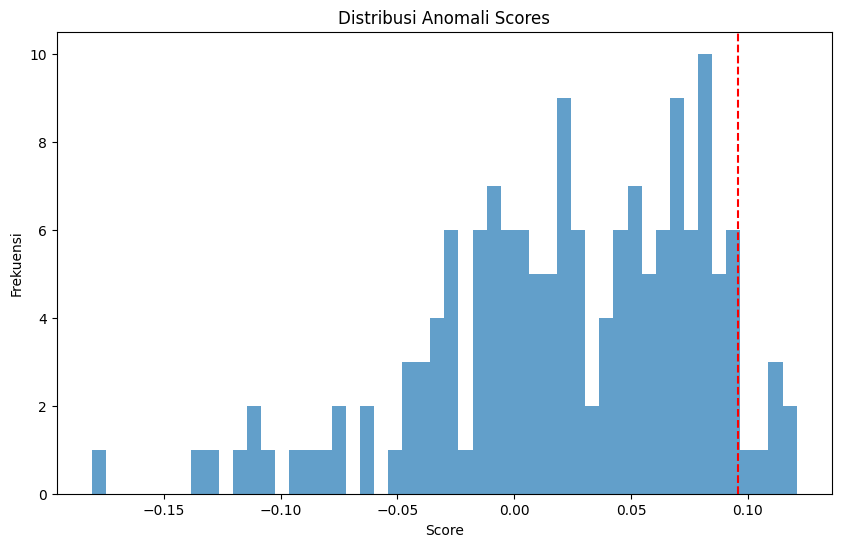

In [117]:
plt.figure(figsize=(10,6))
plt.hist(scores, bins=50, alpha=0.7)
plt.title('Distribusi Anomali Scores')
plt.xlabel('Score')
plt.ylabel('Frekuensi')
plt.axvline(np.percentile(scores, 95), color='r', linestyle='--')
plt.show()


##### UMAP

UMAP (Uniform Manifold Approximation and Projection) adalah teknik dimensionality reduction yang digunakan untuk memproyeksikan data dari ruang dimensi tinggi ke dimensi yang lebih rendah (misalnya 2D atau 3D) —  untuk tujuan visualisasi atau pra-pemrosesan sebelum clustering/pembelajaran mesin .

UMAP didasarkan pada teori manifold learning dan topologi, dengan asumsi bahwa data berasal dari sebuah manifold berdimensi rendah yang tertanam di dalam ruang dimensi tinggi.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



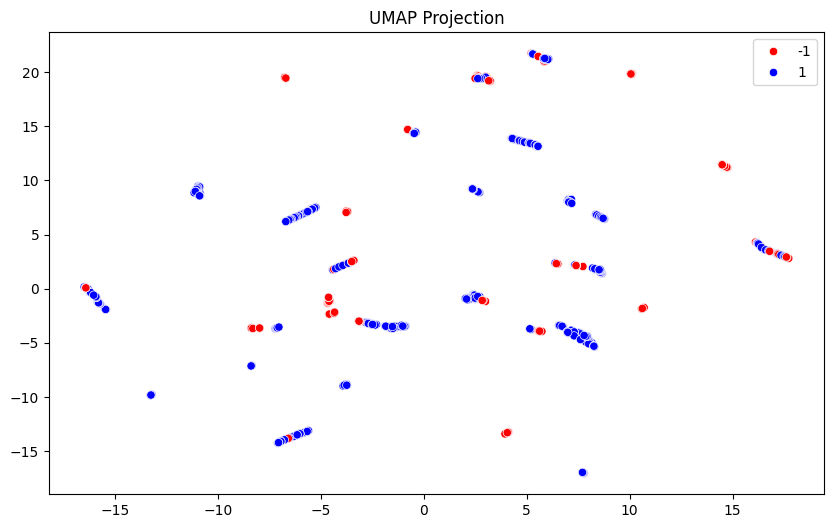

In [118]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1],
                hue=predictions, palette={1:'blue', -1:'red'})
plt.title('UMAP Projection')
plt.show()

In [120]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = px.scatter_3d(x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2],
                    color=predictions,
                    color_discrete_map={1:'blue', -1:'red'},
                    title='3D PCA Visualization')
fig.show()

### Predict Model

In [121]:
X_result = pd.DataFrame(X_scaled, columns=features)
X_result['prediction'] = predictions

In [122]:
X_result

,suhu,kelembaban,karbonmonoksida,kualitasudara,suhu_kelembaban,co_ratio,prediction
0,-0.909091,0.0,1.561957,2.78,-0.909091,-0.087510,-1
1,-0.909091,-0.5,1.538180,2.80,-1.543599,-0.109812,-1
2,-0.454545,-0.5,1.521719,2.72,-1.098330,-0.090919,-1
3,-0.454545,-0.5,1.503429,2.80,-1.098330,-0.131701,-1
4,-0.454545,-0.5,1.510745,2.76,-1.098330,-0.112586,-1
...,...,...,...,...,...,...,...
773,0.363636,0.5,-0.058528,5.88,1.024119,-1.584800,-1
774,0.363636,0.5,-0.071331,5.86,1.024119,-1.588291,-1
775,0.363636,0.5,-0.129858,5.82,1.024119,-1.609802,-1
776,0.363636,0.5,-0.122542,5.72,1.024119,-1.596052,-1


### Prediksi Tiap Feature

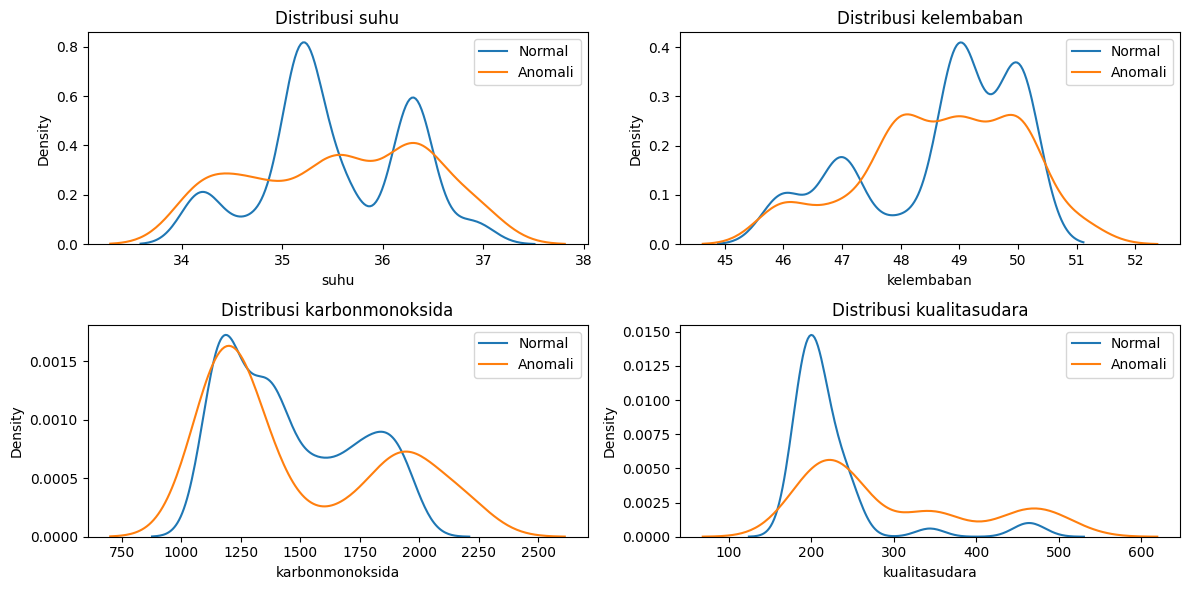

In [123]:
anomalies = df[predictions == -1]
normal = df[predictions == 1]

plt.figure(figsize=(12,6))
for i, col in enumerate(features[:4]):
    plt.subplot(2,2,i+1)
    sns.kdeplot(normal[col], label='Normal')
    sns.kdeplot(anomalies[col], label='Anomali')
    plt.title(f'Distribusi {col}')
    plt.legend()
plt.tight_layout()
plt.show()

### PCA & Visualisasi

In [124]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_result['pca1'] = X_pca[:, 0]
X_result['pca2'] = X_pca[:, 1]

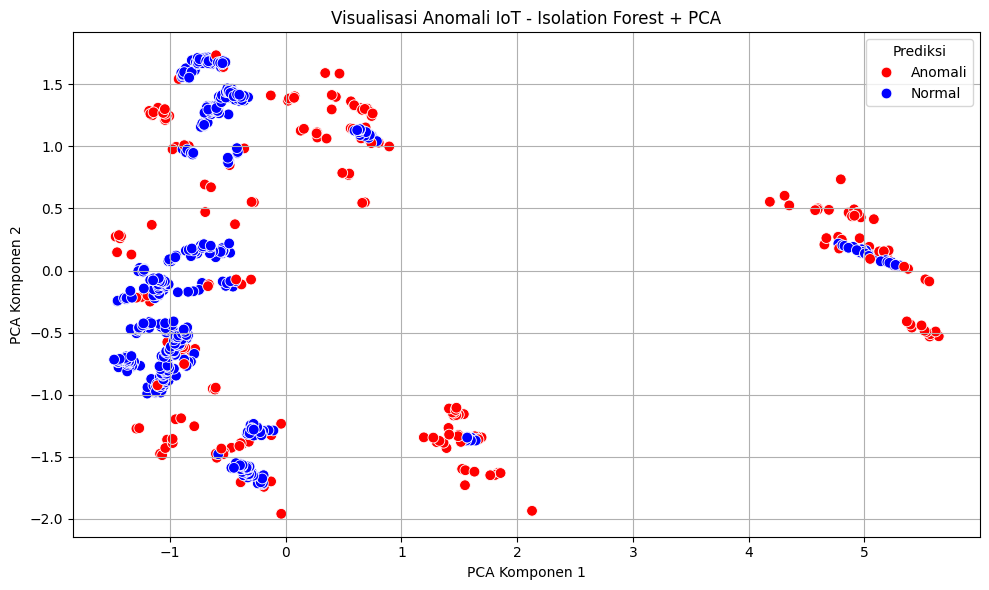

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

X_result['label'] = X_result['prediction'].map({1: 'Normal', -1: 'Anomali'})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='pca1', y='pca2',
    hue='label',
    data=X_result,
    palette={'Normal': 'blue', 'Anomali': 'red'},
    s=60
)

plt.title("Visualisasi Anomali IoT - Isolation Forest + PCA")
plt.xlabel("PCA Komponen 1")
plt.ylabel("PCA Komponen 2")
plt.legend(title="Prediksi")
plt.grid(True)
plt.tight_layout()
plt.show()


In [126]:
loadings = pd.DataFrame(
    pca.components_.T[:, :2],
    columns=['PCA Komponen 1', 'PCA Komponen 2'],
    index=features
)
print("\nKontribusi fitur terhadap PCA:")
print(loadings)


Kontribusi fitur terhadap PCA:
                 PCA Komponen 1  PCA Komponen 2
suhu                   0.093455        0.601812
kelembaban             0.093605       -0.494518
karbonmonoksida       -0.055891       -0.471873
kualitasudara          0.907160       -0.162532
suhu_kelembaban        0.219971       -0.056086
co_ratio              -0.328715       -0.375563


In [127]:
final_output = X.copy()
final_output['prediction'] = predictions
final_output.to_csv("hasil_deteksi_anomali.csv", index=False)
print("\nHasil deteksi disimpan ke 'hasil_deteksi_anomali.csv'")


Hasil deteksi disimpan ke 'hasil_deteksi_anomali.csv'


### Test data

In [180]:
input_data = pd.DataFrame([{
    'suhu': 35.2,
    'kelembaban': 50,
    'karbonmonoksida': 	1512,
    'kualitasudara': 191 ,
    'suhu_kelembaban': 35.2 * 67,
    'co_ratio': 1512 / (191 + 1e-6)
}])

In [181]:
input_scaled = scaler.transform(input_data)


In [182]:
pred_label = model.predict(input_scaled)[0]
score = model.decision_function(input_scaled)[0]

In [183]:
if pred_label == -1:
    print("⚠️ Udara terdeteksi sebagai ANOMALI!")
else:
    print("✅ Udara ini NORMAL.")

print(f"Skor anomali: {score:.4f}")

✅ Udara ini NORMAL.
Skor anomali: 0.0103


### Hasil

Dataset yang digunakan dalam proyek ini merupakan data dari sensor IoT yang merekam parameter lingkungan seperti kelembapan, suhu, kualitas udara, dan kadar karbonmonoksida (CO). Data ini digunakan untuk membangun sistem deteksi anomali berbasis machine learning.

Langkah awal dilakukan pembersihan data dengan menghilangkan nilai kosong (null) dan meninjau distribusi statistik untuk memahami karakteristik masing-masing fitur. Setelah itu, data dianalisis lebih lanjut menggunakan Principal Component Analysis (PCA) untuk mereduksi dimensi dan memvisualisasikan persebaran data dalam dua komponen utama.

Model yang digunakan adalah Isolation Forest, yaitu algoritma deteksi anomali berbasis ensemble decision tree yang bekerja secara unsupervised. Isolation Forest bekerja dengan cara mengisolasi data secara acak dalam pohon-pohon, sehingga data yang mudah diisolasi diasumsikan sebagai anomali. Model ini dipilih karena ringan, cepat, dan sangat cocok untuk data berdimensi tinggi seperti data sensor IoT.

Setelah dilatih, model memberikan skor anomali dan label untuk setiap data: -1 menunjukkan data anomali dan 1 menunjukkan data normal. Hasil dari model divisualisasikan menggunakan scatter plot PCA, yang menunjukkan bahwa data anomali tersebar di luar kluster utama data normal. Ini menunjukkan bahwa model berhasil mengidentifikasi data yang menyimpang secara statistik.

Model ini kemudian dapat digunakan untuk memprediksi secara real-time kondisi lingkungan, dengan mendeteksi apakah data sensor yang baru termasuk dalam kategori normal atau anomali. Sistem ini sangat potensial untuk digunakan dalam aplikasi monitoring kualitas udara otomatis yang dapat memberikan peringatan dini terhadap kondisi yang tidak normal.